# TD3 – Exercise 2: Char-level English → French seq2seq with LSTM


1. Download the file fra.txt from Moodle. Load the file and display some examples.
2. From the text, extract input/target couples that contains english sequences
(inputs) and french ones (targets). Build in the same time the set of unique
characters for both english and french sequences.
3. Build the char2int and int2char dictionaries for both the input and the target
sequences.
4. Generate the training dataset:
a. Two Xs vectors that contains the int values of the sequences to encode and
to decode
b. One ys vector that contains the target sequence to be outputted by the
decoder
5. Build the following Encoder-Decoder architecture:
a. A LSTM layer (encoder) of 256 units which states are connected to a
second LSTM layer (decoder)
b. A LSTM layer (decoder) of 256 units which outputs are connected to the
next dense layer
c. A Dense layer with as many neurons as there are number of characters in
the target dictionary, with a softmax activation function.
6. Compile and train the model with the following parameters:
a. Adam optimizer with a learning rate of 0.01, beta_1 of 0.9, beta_2 of 0.999
and a decay of 0.001
b. Categorical crossentropy loss
c. Batch size of 32
d. 50 epochs
e. Validation split of 0.2
7. Rebuild a model using the parameters previously trained
8. Define a decoder function that feeds the model with an input sequence:
a. Calculate the LSTM states of the encoder
b. Generate a sequence of characters using the encoded states and the
previously predicted sequence.
9. Evaluate the model with sentences from the dataset.

In [1]:
# Import required libraries
import os

import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Data Path
ON_KAGGLE = os.path.exists('/kaggle')
KAGGLE_DATA_DIR = '/kaggle/input/mecbeth'
DATA_DIR = KAGGLE_DATA_DIR

text_path = os.path.join(DATA_DIR, 'fra.txt')
print('Using parallel corpus file:', text_path)
assert os.path.exists(text_path), 'fra.txt not found at: ' + text_path


2026-01-27 14:26:46.724894: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769524007.232500      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769524007.390137      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769524008.655070      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769524008.655115      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769524008.655118      24 computation_placer.cc:177] computation placer alr

Using parallel corpus file: /kaggle/input/mecbeth/fra.txt


In [2]:
# 1. Load the file and display some examples
num_samples = 10000
input_texts = []  # English
target_texts = []  # French (with start/end tokens)
input_chars = set()
target_chars = set()

with open(text_path, "r", encoding="utf-8") as f:
    lines = f.read().split("\n")

print("Total lines in file:", len(lines))
print("First 10 raw lines:")
for line in lines[:10]:
    print(line)

print("\nPreparing sentence pairs...")
for line in lines[:num_samples]:
    if not line:
        continue
    parts = line.split("\t")
    if len(parts) < 2:
        continue
    input_text, target_text = parts[0], parts[1]
    # add start and end tokens on the French side
    target_text = "\t" + target_text + "\n"  # \t = start, \n = end

    input_texts.append(input_text)
    target_texts.append(target_text)

    for ch in input_text:
        input_chars.add(ch)
    for ch in target_text:
        target_chars.add(ch)

print("Number of sentence pairs used:", len(input_texts))

input_chars = sorted(list(input_chars))
target_chars = sorted(list(target_chars))

num_encoder_tokens = len(input_chars)
num_decoder_tokens = len(target_chars)

print("Number of unique input chars:", num_encoder_tokens)
print("Number of unique target chars:", num_decoder_tokens)

max_encoder_seq_length = max(len(txt) for txt in input_texts)
max_decoder_seq_length = max(len(txt) for txt in target_texts)

print("Max encoder seq length:", max_encoder_seq_length)
print("Max decoder seq length:", max_decoder_seq_length)

Total lines in file: 145438
First 10 raw lines:
Go.	Va !
Run!	Cours !
Run!	Courez !
Wow!	Ça alors !
Fire!	Au feu !
Help!	À l'aide !
Jump.	Saute.
Stop!	Ça suffit !
Stop!	Stop !
Stop!	Arrête-toi !

Preparing sentence pairs...
Number of sentence pairs used: 10000
Number of unique input chars: 71
Number of unique target chars: 93
Max encoder seq length: 16
Max decoder seq length: 59


In [3]:
# 3. Build char2int and int2char dictionaries
input_token_index = {ch: i for i, ch in enumerate(input_chars)}
target_token_index = {ch: i for i, ch in enumerate(target_chars)}

reverse_input_char_index = {i: ch for ch, i in input_token_index.items()}
reverse_target_char_index = {i: ch for ch, i in target_token_index.items()}

# 4. Generate training data (one-hot encoding)
encoder_input_data = np.zeros(
    (len(input_texts), max_encoder_seq_length, num_encoder_tokens),
    dtype='float32',
)
decoder_input_data = np.zeros(
    (len(input_texts), max_decoder_seq_length, num_decoder_tokens),
    dtype='float32',
)
decoder_target_data = np.zeros(
    (len(input_texts), max_decoder_seq_length, num_decoder_tokens),
    dtype='float32',
)

for i, (input_text, target_text) in enumerate(zip(input_texts, target_texts)):
    for t, ch in enumerate(input_text):
        encoder_input_data[i, t, input_token_index[ch]] = 1.0
    # rest stays zero (padding)

    for t, ch in enumerate(target_text):
        decoder_input_data[i, t, target_token_index[ch]] = 1.0
        if t > 0:
            # decoder_target_data is shifted by one timestep
            decoder_target_data[i, t - 1, target_token_index[ch]] = 1.0

print('encoder_input_data shape:', encoder_input_data.shape)
print('decoder_input_data shape:', decoder_input_data.shape)
print('decoder_target_data shape:', decoder_target_data.shape)


encoder_input_data shape: (10000, 16, 71)
decoder_input_data shape: (10000, 59, 93)
decoder_target_data shape: (10000, 59, 93)


In [4]:
# 5. Build the encoder–decoder model
latent_dim = 256

# Encoder
encoder_inputs = Input(shape=(None, num_encoder_tokens))
encoder_lstm = LSTM(latent_dim, return_state=True)
_, state_h, state_c = encoder_lstm(encoder_inputs)
encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(shape=(None, num_decoder_tokens))
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)
decoder_dense = Dense(num_decoder_tokens, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

# Full training model
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.summary()

# 6. Compile and train the model
optimizer = Adam(learning_rate=0.01, beta_1=0.9, beta_2=0.999, decay=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy')

EPOCHS = 50
BATCH_SIZE = 32

history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    verbose=1,
)


I0000 00:00:1769524032.054233      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1769524032.054969      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None, 71)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, None, 93)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 256),     │    335,872 │ input_layer[0][0] │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, None,     │    358,400 │ input_layer_1[0]… │
│                     │ 256), (None,      │            │ lstm[0][1],       │
│                     │ 256), (None,      │            │ lstm[0][2]        │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None, 93)  │     23,901 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 718,173 (2.74 MB)

 Trainable params: 718,173 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/50


I0000 00:00:1769524037.671867      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.9926 - val_loss: 1.0454
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.8438 - val_loss: 1.0688
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.8415 - val_loss: 1.0261
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.8195 - val_loss: 0.9498
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.7831 - val_loss: 0.9259
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.7529 - val_loss: 0.8816
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.7324 - val_loss: 0.8923
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.7127 - val_loss: 0.8814
Epoch 9/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.6926 - val_loss: 0.8310
Epoch 10/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.6919 - val_loss: 0.8104
Epoch 11/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.6207 - val_loss: 0.7827
Epoch 12/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0

In [5]:
# 7. Rebuild inference models for encoder and decoder
encoder_model = Model(encoder_inputs, encoder_states)

# Decoder inference setup
decoder_state_input_h = Input(shape=(latent_dim,))
decoder_state_input_c = Input(shape=(latent_dim,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_outputs_inf, state_h_inf, state_c_inf = decoder_lstm(
    decoder_inputs, initial_state=decoder_states_inputs
)
decoder_states_inf = [state_h_inf, state_c_inf]
decoder_outputs_inf = decoder_dense(decoder_outputs_inf)

decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs,
    [decoder_outputs_inf] + decoder_states_inf,
)


In [6]:
# 8. Define decode_sequence() to generate French sentences
def decode_sequence(input_seq):
    """Decode a single input sequence to a French sentence."""
    # Encode the input as state vectors
    states_value = encoder_model.predict(input_seq)

    # Generate empty target sequence with only the start character
    target_seq = np.zeros((1, 1, num_decoder_tokens), dtype='float32')
    target_seq[0, 0, target_token_index['\t']] = 1.0

    decoded_sentence = ''

    while True:
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value)

        # Sample a token
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_char = reverse_target_char_index[sampled_token_index]
        decoded_sentence += sampled_char

        # Exit condition: hit max length or find stop character.
        if sampled_char == '\n' or len(decoded_sentence) > max_decoder_seq_length:
            break

        # Update the target sequence (length 1)
        target_seq = np.zeros((1, 1, num_decoder_tokens), dtype='float32')
        target_seq[0, 0, sampled_token_index] = 1.0

        # Update states
        states_value = [h, c]

    return decoded_sentence


In [7]:
# 9. Evaluate the model on some samples
print('Some translation examples (not perfect, but for inspection):\n')
for seq_index in range(10):
    input_seq = encoder_input_data[seq_index : seq_index + 1]
    decoded_sentence = decode_sequence(input_seq)

    print('Input English:  ', input_texts[seq_index])
    print('Target French:  ', target_texts[seq_index].strip())
    print('Decoded French: ', decoded_sentence.strip())
    print('-')


Some translation examples (not perfect, but for inspection):

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Input English:   Go.
Target French:   Va !
Decoded French:  Prenez teste !
-
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━

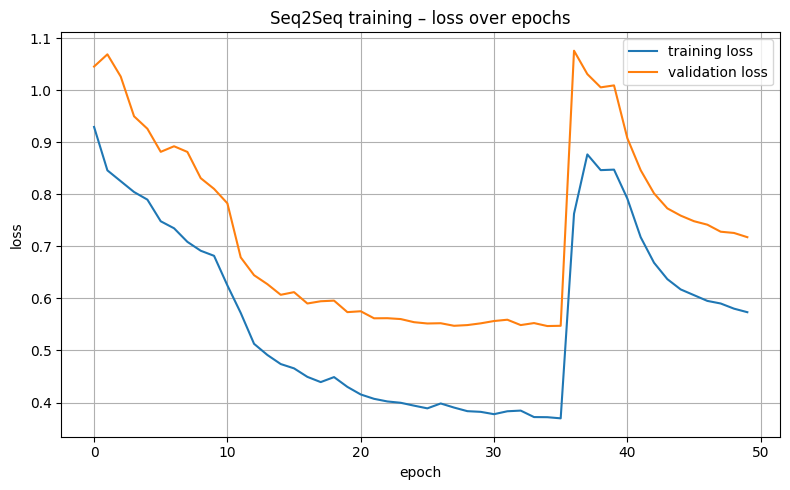

In [8]:
# history is the object returned by model.fit()
history_dict = history.history

loss = history_dict.get("loss", [])
val_loss = history_dict.get("val_loss", [])

plt.figure(figsize=(8, 5))
plt.plot(loss, label="training loss")
if len(val_loss) > 0:
    plt.plot(val_loss, label="validation loss")

plt.title("Seq2Seq training – loss over epochs")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## My Observation

after training for a while, i see that the model starts to produce french sentences that are not exactly the same as the reference, but they often keep the general meaning and a similar length. small words like "i", "you", "we" and some simple verbs are usually translated in a reasonable way.

sometimes the decoder repeats a word or forgets some accents and punctuation. it also mixes verb tenses, because at the end of the day this is only a character model, so it does not really understand grammar. still, for a pure char‑level system with a relatively small lstm, the behaviour looks quite impressive to me.

when i reduce the number of sentence pairs or the number of epochs, the translations become much worse, so it seems that the model really needs enough data and training time to build a good internal picture of both english and french sequences.
